In [2]:
from analyses import parse
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl
import numpy as np
import colorir as cl
from pathlib import Path
from tqdm import tqdm

In [22]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    gamma = 20 - int(sim_type.split("-")[1])
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(gamma, replica)] = replica_path
sims = parse.parse_cells_multiple(sim_paths.values(), 30)
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        gamma=sim_ids[i][0], 
        replica=sim_ids[i][1]
    )
cellveldf = pl\
    .concat(sims)\
    .with_columns(
        displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2).sqrt()
    )
cellveldf

index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,wtime,gamma,replica,displ
u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,i32,i32,i32,f32
0,0,201,200,182,180,209.079208,316.838074,208.964035,316.836914,65994,84,69,10600000,4,1,379.605682
1,1,200,200,184,180,461.637848,416.135437,461.779175,416.303436,17285,62,196,10600000,4,1,621.512817
2,2,200,200,186,180,209.271759,106.904106,209.287857,106.870018,94594,187,155,10600000,4,1,234.996078
3,3,201,200,182,180,258.85376,317.87677,258.78717,317.875244,59906,27,172,10600000,4,1,409.940125
4,4,200,200,182,180,371.157166,217.356934,371.143494,217.177246,55579,19,215,10600000,4,1,430.118195
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
95,95,200,200,186,180,135.854111,90.685593,135.833038,90.6437,108919,229,31,11300000,10,4,163.340805
96,96,200,200,182,180,60.278709,88.606598,60.294647,88.631836,120135,118,216,11300000,10,4,107.166473
97,97,200,200,180,180,111.946625,63.425114,111.986275,63.418514,115850,73,3,11300000,10,4,128.665436


In [23]:
grouppers = ["gamma", "replica", "wtime"]
displdf = cellveldf.group_by(grouppers).agg(
    cluster_x=pl.col("center_x").mean(),
    cluster_y=pl.col("center_y").mean(),
    mean_displ=pl.col("displ").mean(),
    med_displ=pl.col("displ").median()
).sort(grouppers)
displdf

gamma,replica,wtime,cluster_x,cluster_y,mean_displ,med_displ
i32,i32,i32,f32,f32,f32,f32
0,0,0,433.300049,433.299988,614.067871,615.056519
0,0,100000,374.361847,362.397461,530.212097,546.781738
0,0,200000,318.912354,323.1073,474.199799,478.11142
0,0,300000,287.697052,289.229279,430.144165,467.157349
0,0,400000,280.46048,275.529236,425.530945,445.333221
…,…,…,…,…,…,…
20,4,14500000,77.122459,74.833153,116.028175,122.764511
20,4,14600000,82.664749,79.359482,121.106537,124.670845
20,4,14700000,89.211922,73.46209,122.026901,123.379669


In [66]:
max_time = displdf["wtime"].max()
stdf = displdf\
    .group_by(["gamma"])\
    .agg(
        stime=pl.col("wtime")\
            .filter(
                pl.col("mean_displ") <= pl.col("mean_displ").filter(pl.col("wtime") > 1e7).mean()
            )\
            .min(),
        ptime=pl.col("wtime")\
            .filter(
                pl.col("mean_displ") <= 180
            )\
            .min().fill_null(max_time)
    )
stdf

gamma,stime,ptime
i32,i32,i32
0,600000,14900000
2,700000,14900000
4,600000,14900000
6,700000,14900000
8,1000000,14900000
…,…,…
12,1400000,1300000
14,1500000,1400000
16,1700000,1500000


In [5]:
# These sims should contain a single cell!!
sim_paths = {}
for sp in Path("../runs/msd/").iterdir():
    sim_type = sp.name
    gamma = 20 - int(sim_type.split("-")[1])
    for p in sp.iterdir():
        replica = int(p.name)
        sim_paths[(gamma, replica)] = p
    
sims = parse.parse_cells_multiple(
    sim_paths.values(),
    n_workers=24
)
celldf = pl.concat([sim.with_columns(gamma=k[0], replica=k[1]) for k, sim in zip(sim_paths, sims)])
assert (celldf["index"] == 0).all()
celldf

index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,time,wtime,gamma,replica
u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,u32,i32,i32,i32
0,0,200,200,184,180,158.657257,388.343842,158.62294,388.2854,57702,238,142,3100010,3200000,4,7
0,0,199,200,180,180,158.856522,388.571716,158.819427,388.515686,57358,238,142,3100020,3200000,4,7
0,0,200,200,176,180,159.037231,388.478821,158.998245,388.423553,57650,238,142,3100030,3200000,4,7
0,0,200,200,182,180,158.502228,388.238892,158.460159,388.182404,57735,238,142,3100040,3200000,4,7
0,0,200,200,178,180,158.19223,388.14389,158.148315,388.092041,57774,238,142,3100050,3200000,4,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,200,200,188,180,65.742638,94.061111,65.690964,94.061043,118622,30,141,1899960,1900000,16,8
0,0,199,200,182,180,65.419739,94.20211,65.368362,94.200859,118046,30,141,1899970,1900000,16,8
0,0,200,200,188,180,65.327629,93.826118,65.274567,93.821739,118714,30,141,1899980,1900000,16,8


In [106]:
interval = 1000
dts = np.concat([
    [10], 
    np.arange(
        interval,
        3_000_000 + interval,
        interval,
        dtype=int
    )
])
# All numbers must be divisible by 10
assert np.equal(np.mod(dts / 10, 1), 0).all()
dts

array([     10,    1000,    2000, ..., 2998000, 2999000, 3000000],
      shape=(3001,))

In [113]:
filterdf = celldf.select(
    "gamma",
    "replica",
    "time",
    "center_x",
    "center_y",
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
).filter(
    # Optional gamma filtering
    pl.col("gamma").is_in([0, 20]),
    pl.col("time") > 1e5,
).join(
    stdf, 
    on="gamma"
).filter(
    # Using ptime, change to stime if needed
    pl.col("time") < pl.col("stime"),
).sort([
    "gamma", 
    "replica",
    "time"
])
filterdf

gamma,replica,time,center_x,center_y,displ,stime,ptime
i32,i32,u32,f32,f32,f32,i32,i32
0,0,100010,349.577087,195.533951,400.546722,600000,14900000
0,0,100020,349.857086,195.118988,400.588837,600000,14900000
0,0,100030,350.102142,195.173965,400.82962,600000,14900000
0,0,100040,350.362183,194.898972,400.923004,600000,14900000
0,0,100050,350.803192,195.247726,401.477966,600000,14900000
…,…,…,…,…,…,…,…
20,20,3499950,50.207645,137.286819,146.179611,3500000,3200000
20,20,3499960,50.733974,137.165985,146.247879,3500000,3200000
20,20,3499970,51.289097,136.97171,146.25943,3500000,3200000


In [114]:
msddfs = []
groupped = filterdf.group_by(["gamma", "replica"])
for dt in tqdm(dts, mininterval=2):
    msd = groupped\
        .agg(
            len=pl.col("center_x").diff(n=dt / 10).drop_nulls().len(),
            msd=(
                pl.col("center_x").diff(n=dt / 10) ** 2
                + pl.col("center_y").diff(n=dt / 10) ** 2
            ).mean()
        )\
        .with_columns(dt=dt).filter(pl.col("len") >= 10)
    msddfs.append(msd)
msddf = pl.concat(msddfs)

100%|██████████████████████████████████████████████████████| 3001/3001 [06:15<00:00,  7.99it/s]


In [115]:
aggdf = msddf.group_by(["gamma", "dt"]).agg(
    mean=pl.col("msd").mean(),
    med=pl.col("msd").median(),
    min=pl.col("msd").min(),
    max=pl.col("msd").max(),
    std1=pl.col("msd").mean() + 1.5 * pl.col("msd").std(),
    std2=pl.col("msd").mean() - 1.5 * pl.col("msd").std()
).sort("dt").with_columns(
    pl.exclude(["gamma", "replica"]).log().name.prefix("ln_")
)
aggdf

gamma,dt,mean,med,min,max,std1,std2,ln_dt,ln_mean,ln_med,ln_min,ln_max,ln_std1,ln_std2
i32,i64,f32,f32,f32,f32,f32,f32,f64,f32,f32,f32,f32,f32,f32
0,10,0.654181,0.669649,0.463263,0.869159,0.846547,0.461815,2.302585,-0.424372,-0.401001,-0.76946,-0.140229,-0.16659,-0.772591
20,10,0.118888,0.118464,0.106044,0.132573,0.129439,0.108336,2.302585,-2.129575,-2.133146,-2.243897,-2.020621,-2.044543,-2.222515
0,1000,340.802673,340.071136,193.70723,508.34256,485.225159,196.380188,6.907755,5.831304,5.829155,5.266348,6.231156,6.184614,5.280053
20,1000,18.546917,18.792427,14.316825,23.521833,22.331974,14.76186,6.907755,2.920304,2.933454,2.661436,3.157929,3.10602,2.692047
0,2000,672.046265,692.622742,375.750641,1022.223633,969.439331,374.653229,7.600902,6.510328,6.540486,5.928926,6.929736,6.876719,5.926002
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20,2996000,135245.46875,135020.546875,39951.710938,244922.46875,222483.15625,48007.78125,14.912789,11.814848,11.813183,10.595428,12.408698,12.312608,10.779119
20,2997000,135351.984375,135095.171875,39954.183594,245111.3125,222649.09375,48054.882812,14.913122,11.815635,11.813736,10.59549,12.409469,12.313354,10.7801
20,2998000,135459.46875,135158.21875,39954.980469,245307.609375,222818.984375,48099.953125,14.913456,11.816429,11.814202,10.59551,12.410269,12.314116,10.781037


In [116]:
palette = cl.StackPalette().load("carnival")
grad = cl.PolarGrad(palette, domain=[0, 20])
palette

/tmp/ipykernel_3099810/3214442565.py:1: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



     #e7f8bf
     #98d5a4
     #3faf99
     #008692
     #005986
     #3b2179
     #823083
     #b75687
     #dd867f
     #f4bc77
     #f8f68b

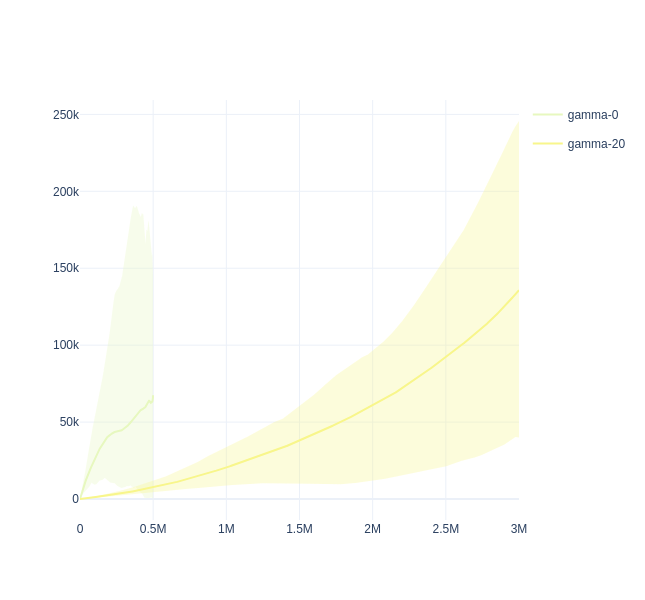

In [117]:
fig = go.Figure()
for gamma, group in aggdf.group_by("gamma"):
    gamma = gamma[0]
    color = grad(gamma)
    fig.add_traces([
        go.Scatter(
            x=group["dt"],
            y=group["mean"],
            mode="lines",
            line_color=color,
            name=f"gamma-{gamma}",
            legendgroup=gamma
        ),
        go.Scatter(
            x=pl.concat([group["dt"], group["dt"][::-1]]),
            y=pl.concat([group["min"], group["max"][::-1]]),
            mode="lines",
            line_color="rgba(0, 0, 0, 0)",
            fillcolor=color,
            opacity=0.3,
            fill="toself",
            hoverinfo="skip",
            showlegend=False,
            legendgroup=gamma
        )
    ])
fig.update_layout(
    template="plotly_white",
    width=400,
    height=600
)

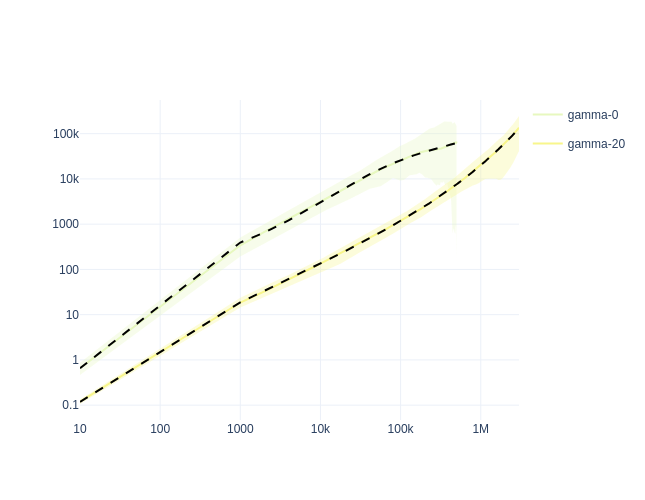

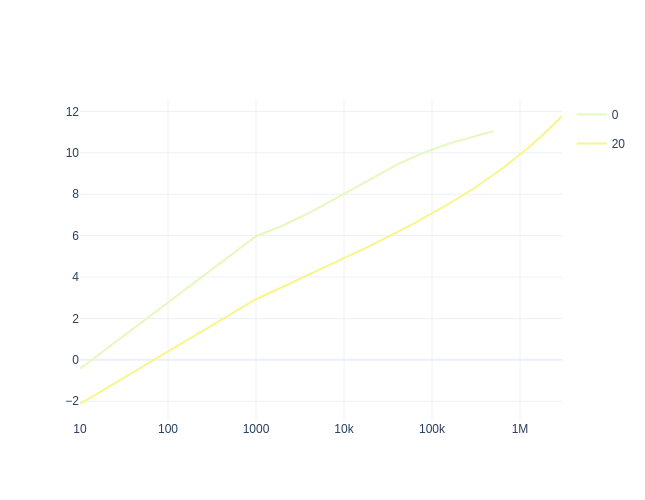

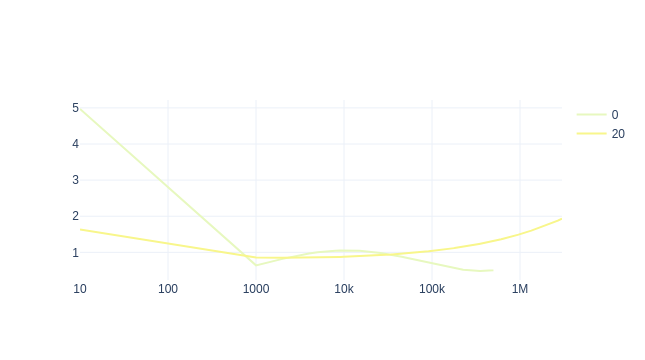

In [118]:
fig2 = go.Figure(fig.update_layout(
    xaxis_type="log",
    yaxis_type="log",
    width=500,
    height=500
))
fig3 = go.Figure()
fig4 = go.Figure()
for gamma, group in aggdf.group_by("gamma"):
    gamma = gamma[0]
    dt = group["dt"]
    log_dt = dt.log()
    mean = group["mean"]
    poly = np.polynomial.Polynomial.fit(x=dt.log(), y=mean.log(), deg=5).convert()
    fig2.add_trace(go.Scatter(
        x=dt,
        y=np.exp(poly(dt.log())),
        mode="lines",
        line_dash="dash",
        line_color="#000000",
        showlegend=False,
        legendgroup=gamma
    ))

    fig3.add_trace(go.Scatter(
        x=np.exp(log_dt),
        y=poly(log_dt),
        mode="lines",
        line_color=grad(gamma),
        name=gamma,
        legendgroup=gamma
    ))
    
    first_deriv = poly.deriv()
    fig4.add_trace(go.Scatter(
        x=np.exp(log_dt),
        y=first_deriv(log_dt),
        mode="lines",
        line_color=grad(gamma),
        name=str(gamma)
    ))
fig2.show()
fig3.update_layout(
    template="plotly_white",
    xaxis_type="log",
    width=500,
    height=500
).show()
fig4.update_layout(
    template="plotly_white",
    xaxis_type="log"
)